<a href="https://colab.research.google.com/github/AiEmStylix/btc_prediction/blob/main/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dữ liệu: 362 ngày, từ 2025-03-06 00:00:00 -> 2026-03-02 00:00:00
Tỷ lệ ngày giá TĂNG: 49.0% | ngày giá GIẢM/đứng yên: 51.0%

  Thử nghiệm: OHLCV + Sentiment
Train: (292, 14, 11) | Test: (41, 14, 11)
Train - tỷ lệ tăng: 51.4% | Test - tỷ lệ tăng: 41.5%
[Baseline ngây thơ - luôn đoán lớp '1'] Accuracy: 0.415  <- model PHẢI thắng con số này mới coi là có học được gì
Class weight: {np.int64(0): np.float64(1.028169014084507), np.int64(1): np.float64(0.9733333333333334)}
Dừng ở epoch 21


Phân bố xác suất dự đoán - min: 0.470 | max: 0.504 | mean: 0.494 | std: 0.0095
⚠️  CẢNH BÁO: độ lệch chuẩn xác suất dự đoán gần 0 -> model đang xuất ra gần như cùng 1 giá trị cho mọi mẫu (MODEL COLLAPSE), chưa thực sự phân biệt được các mẫu.
Ngưỡng phân loại tối ưu (Youden's J): 0.501 (thay vì mặc định 0.5)

Accuracy: 0.659 | Precision: 0.714 | Recall: 0.294 | F1: 0.417 | AUC: 0.532
Confusion matrix:
 [[22  2]
 [12  5]]

Classification report:
               precision    recall  f1-score   support

    Giảm (0)       0.65      0.92      0.76        24
    Tăng (1)       0.71      0.29      0.42        17

    accuracy                           0.66        41
   macro avg       0.68      0.61      0.59        41
weighted avg       0.67      0.66      0.62        41


  Thử nghiệm: OHLCV thuần (baseline)
Train: (292, 14, 5) | Test: (41, 14, 5)
Train - tỷ lệ tăng: 51.4% | Test - tỷ lệ tăng: 41.5%
[Baseline ngây thơ - luôn đoán lớp '1'] Accuracy: 0.415  <- model PHẢI thắng con số này mới c

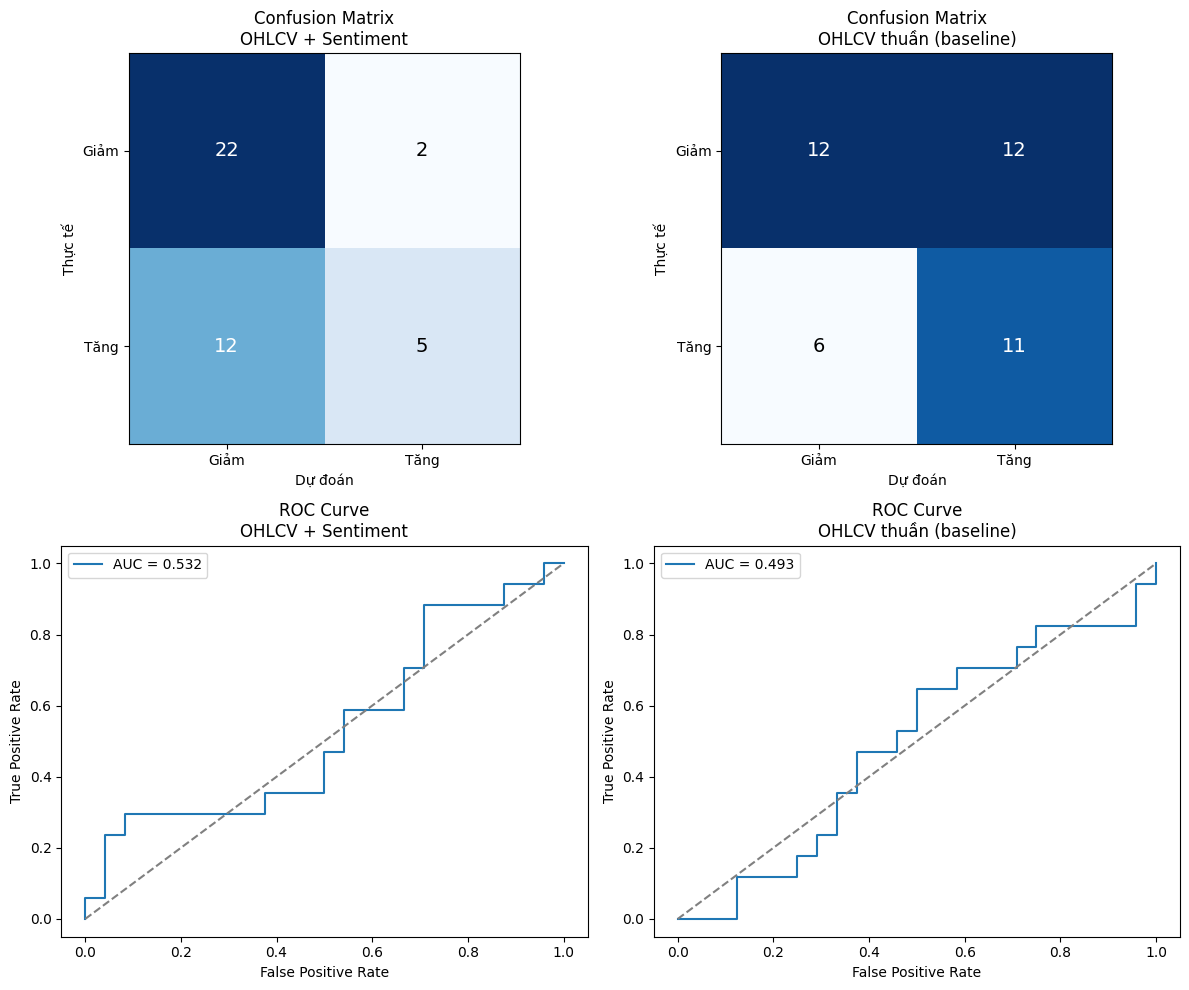

In [ ]:
"""
Bước 3 (bản Classification): Dự đoán XU HƯỚNG giá BTC (tăng/giảm) bằng BiLSTM
Đọc dữ liệu đã xử lý từ merged_dataset.csv (output của coverage.py)

- Theo dõi val_auc thay vì val_loss cho Early Stopping
- Giảm dropout 0.3 -> 0.2 (model nhỏ + ít dữ liệu, dropout cao dễ underfit)
- In phân bố xác suất dự đoán để phát hiện model collapse ngay khi xảy ra
- Thêm baseline "always predict majority class" để so sánh - nếu model
  không thắng nổi baseline ngây thơ này, model coi như chưa học được gì
- Tìm ngưỡng phân loại tối ưu bằng chỉ số Youden's J = TPR - FPR
  thay vì cố định 0.5 (giúp phát hiện nếu model có tín hiệu nhưng bị lệch ngưỡng)
"""
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# ============================================================
# 0. Cố định tính ngẫu nhiên (Reproducibility)
# ============================================================
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# 1. Đọc dữ liệu đã xử lý
# ============================================================
data = pd.read_csv("merged_dataset.csv")
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date').reset_index(drop=True)
print(f"Dữ liệu: {len(data)} ngày, từ {data['date'].min()} -> {data['date'].max()}")

# ============================================================
# 2. Tạo biến mục tiêu: XU HƯỚNG (1 = tăng, 0 = giảm/đứng yên)
# ============================================================
data['direction'] = (data['close'].diff() > 0).astype(int)
data = data.iloc[1:].reset_index(drop=True)

up_ratio = data['direction'].mean() * 100
print(f"Tỷ lệ ngày giá TĂNG: {up_ratio:.1f}% | ngày giá GIẢM/đứng yên: {100 - up_ratio:.1f}%")

WINDOW = 14
feature_cols_full = ['open', 'high', 'low', 'close', 'volume',
                      'sentiment_mean', 'tweet_count', 'pos_ratio', 'neg_ratio',
                      'has_tweet_flag', 'days_since_tweet']
feature_cols_baseline = ['open', 'high', 'low', 'close', 'volume']
target_col = 'direction'


def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)


def build_model(n_features, window):
    model = Sequential([
        Input(shape=(window, n_features)),
        Bidirectional(LSTM(32, return_sequences=True, kernel_regularizer=l2(1e-4))),
        Dropout(0.2),
        Bidirectional(LSTM(16, kernel_regularizer=l2(1e-4))),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


def find_best_threshold(y_true, y_proba):
    """Tìm ngưỡng phân loại tối ưu bằng chỉ số Youden's J = TPR - FPR,
    thay vì cố định 0.5 (giúp phát hiện nếu model có tín hiệu nhưng bị lệch ngưỡng)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    return thresholds[best_idx]


def run_experiment(feature_cols, label):
    tf.keras.backend.clear_session()

    print(f"\n{'=' * 60}")
    print(f"  Thử nghiệm: {label}")
    print(f"{'=' * 60}")

    split_idx = int(len(data) * 0.85)
    train_data = data.iloc[:split_idx].copy()
    test_data = data.iloc[split_idx:].copy()

    scaler_X = MinMaxScaler()
    train_X_scaled = scaler_X.fit_transform(train_data[feature_cols])
    test_X_scaled = scaler_X.transform(test_data[feature_cols])

    train_y = train_data[target_col].values
    test_y = test_data[target_col].values

    X_train, y_train = create_sequences(train_X_scaled, train_y, WINDOW)
    X_test, y_test = create_sequences(test_X_scaled, test_y, WINDOW)

    print(f"Train: {X_train.shape} | Test: {X_test.shape}")
    print(f"Train - tỷ lệ tăng: {y_train.mean()*100:.1f}% | Test - tỷ lệ tăng: {y_test.mean()*100:.1f}%")

    # Baseline ngây thơ: luôn đoán lớp đa số trong tập train
    majority_class = int(round(y_train.mean()))
    naive_pred = np.full_like(y_test, majority_class)
    naive_acc = accuracy_score(y_test, naive_pred)
    print(f"[Baseline ngây thơ - luôn đoán lớp '{majority_class}'] Accuracy: {naive_acc:.3f}  <- model PHẢI thắng con số này mới coi là có học được gì")

    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weight = dict(zip(classes, weights))
    print(f"Class weight: {class_weight}")

    model = build_model(n_features=X_train.shape[2], window=WINDOW)
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=200,
        batch_size=16,
        callbacks=[early_stop],
        class_weight=class_weight,
        verbose=0
    )
    print(f"Dừng ở epoch {len(history.history['loss'])}")

    pred_proba = model.predict(X_test, verbose=0).flatten()

    # Chẩn đoán: kiểm tra phân bố xác suất dự đoán
    print(f"Phân bố xác suất dự đoán - min: {pred_proba.min():.3f} | max: {pred_proba.max():.3f} | "
          f"mean: {pred_proba.mean():.3f} | std: {pred_proba.std():.4f}")
    if pred_proba.std() < 0.02:
        print("⚠️  CẢNH BÁO: độ lệch chuẩn xác suất dự đoán gần 0 -> model đang xuất ra gần như"
              " cùng 1 giá trị cho mọi mẫu (MODEL COLLAPSE), chưa thực sự phân biệt được các mẫu.")

    try:
        auc = roc_auc_score(y_test, pred_proba)
    except ValueError:
        auc = float('nan')

    best_thresh = find_best_threshold(y_test, pred_proba) if not np.isnan(auc) else 0.5
    pred_label = (pred_proba >= best_thresh).astype(int)
    print(f"Ngưỡng phân loại tối ưu (Youden's J): {best_thresh:.3f} (thay vì mặc định 0.5)")

    acc = accuracy_score(y_test, pred_label)
    precision = precision_score(y_test, pred_label, zero_division=0)
    recall = recall_score(y_test, pred_label, zero_division=0)
    f1 = f1_score(y_test, pred_label, zero_division=0)
    cm = confusion_matrix(y_test, pred_label)

    print(f"\nAccuracy: {acc:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
    print("Confusion matrix:\n", cm)
    print("\nClassification report:\n",
          classification_report(y_test, pred_label, target_names=['Giảm (0)', 'Tăng (1)'], zero_division=0))

    return {
        'label': label, 'y_test': y_test, 'pred_proba': pred_proba, 'pred_label': pred_label,
        'acc': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'auc': auc, 'cm': cm,
        'naive_acc': naive_acc, 'best_thresh': best_thresh
    }


# ============================================================
# 3. Chạy 2 thử nghiệm
# ============================================================
result_full = run_experiment(feature_cols_full, "OHLCV + Sentiment")
result_base = run_experiment(feature_cols_baseline, "OHLCV thuần (baseline)")

# ============================================================
# 4. So sánh kết quả
# ============================================================
print(f"\n{'=' * 60}")
print("  SO SÁNH KẾT QUẢ")
print(f"{'=' * 60}")
print(f"{'Metric':<20}{'OHLCV+Sentiment':<20}{'OHLCV thuần':<20}")
print(f"{'Accuracy':<20}{result_full['acc']:<20.3f}{result_base['acc']:<20.3f}")
print(f"{'Naive baseline Acc':<20}{result_full['naive_acc']:<20.3f}{result_base['naive_acc']:<20.3f}")
print(f"{'Precision':<20}{result_full['precision']:<20.3f}{result_base['precision']:<20.3f}")
print(f"{'Recall':<20}{result_full['recall']:<20.3f}{result_base['recall']:<20.3f}")
print(f"{'F1-score':<20}{result_full['f1']:<20.3f}{result_base['f1']:<20.3f}")
print(f"{'AUC':<20}{result_full['auc']:<20.3f}{result_base['auc']:<20.3f}")

for r in [result_full, result_base]:
    verdict = "✅ Model có học được tín hiệu" if r['acc'] > r['naive_acc'] and r['auc'] > 0.55 \
        else "❌ Model KHÔNG thắng nổi baseline ngây thơ / AUC quá thấp -> chưa học được gì đáng kể"
    print(f"{r['label']}: {verdict}")

# ============================================================
# 5. Vẽ biểu đồ
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, result in zip(axes[0], [result_full, result_base]):
    cm = result['cm']
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f"Confusion Matrix\n{result['label']}")
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Giảm', 'Tăng'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Giảm', 'Tăng'])
    ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)

for ax, result in zip(axes[1], [result_full, result_base]):
    fpr, tpr, _ = roc_curve(result['y_test'], result['pred_proba'])
    ax.plot(fpr, tpr, label=f"AUC = {result['auc']:.3f}")
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f"ROC Curve\n{result['label']}")
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend()

plt.tight_layout()
plt.savefig("classification_comparison.png", dpi=150)
print("\n✅ Đã lưu biểu đồ: classification_comparison.png")